# 03 - VAR and VECM: Gold and silver

This notebook builds on `01_Data_Exploration.ipynb` (log-prices, log-ratio,
train/val/test split) and `02_Stationarity_and_Cointegration.ipynb` (order of
integration I(1), absence of a stable global cointegration relation, and the
2015–2016 local cointegration episode).

**Objective**: estimate a VAR on the log-returns of gold and silver for the
short-term dynamics, and a VECM restricted to the local cointegration episode
identified in notebook 02, for an exploratory analysis of the long-run
relation.

Granger/instantaneous causality, the Cholesky decomposition, impulse response
functions and the FEVD are covered separately in `05_Causality_and_IRF.ipynb`.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from preprocessing import train_val_test_split, clean_for_model
from stationarity import stationarity_table
from cointegration import rolling_cointegration
from utils import find_significant_intervals
from var_vecm import (
    select_var_lag_order,
    var_diagnostics_table,
    lr_test_nested_var,
    recursive_one_step_forecast_var,
    forecast_accuracy_table,
    select_vecm_lag_order,
    fit_vecm,
    vecm_beta_alpha_tables,
    normalized_long_run_relation,
    compute_ect,
    vecm_summary_table,
    recursive_one_step_forecast_vecm,
    vecm_residual_diagnostics,
)
from plots import plot_forecast_levels

In [3]:
df = pd.read_csv("../data/processed/gold_silver_processed.csv", index_col=0, parse_dates=True)

df_train, df_val, df_test = train_val_test_split(df, train_frac=0.70, val_frac=0.85)

print(f"Training sample: {df_train.index.min().date()} → {df_train.index.max().date()} "
      f"({len(df_train)} observations)")

train_diff_clean = clean_for_model(df_train[["dlog_gold", "dlog_silver"]])
train_diff_clean.head()

Training sample: 2000-08-30 → 2017-09-14 (4275 observations)


,dlog_gold,dlog_silver
Date,,
2000-08-31,0.015937,0.014699
2000-09-01,-0.004682,0.000200
2000-09-05,-0.004342,-0.001200
2000-09-06,-0.005818,-0.003006
2000-09-07,-0.000730,-0.009679


## 1. Bivariate VAR modeling on first differences

### 1.1 Lag order selection

Since the log-prices of gold and silver are non-stationary, the VAR is
estimated on the first differences of the log-prices, i.e. log-returns.

The optimal number of lags is selected after comparing different information criteria
(AIC, BIC, HQIC, FPE) and Likelihood Ratio. Several dynamic specifications are then compared to
assess the econometric quality of the estimated models.

In [4]:
lag_selection = select_var_lag_order(train_diff_clean, maxlags=10)
lag_selection.summary()

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-17.69*,-17.69*,2.078e-08*,-17.69*
1,-17.69,-17.68,2.080e-08,-17.69
2,-17.69,-17.67,2.078e-08,-17.68
3,-17.69,-17.67,2.082e-08,-17.68
4,-17.69,-17.66,2.082e-08,-17.68
5,-17.69,-17.65,2.084e-08,-17.67
6,-17.69,-17.65,2.081e-08,-17.67
7,-17.69,-17.64,2.082e-08,-17.67
8,-17.69,-17.64,2.080e-08,-17.67
9,-17.69,-17.63,2.082e-08,-17.67


The information criteria all point to lag 0 as the minimum, which is not
usable in practice: a VAR(0) has no autoregressive dynamics at all. This
ambiguity is expected with daily financial returns, whose autocorrelation
structure is typically very weak.
The raw AIC/BIC/FPE/HQIC ranking cannot be used on its own to pick a final lag order.

The following sections therefore bring in complementary criteria (residual
diagnostics (whiteness, normality) across candidate lags, LR tests between
nested VAR specifications, and out-of-sample validation (MAPE) ) to select
a lag order that is both statistically defensible and useful for forecasting.

### 1.2 Diagnostics of candidate VAR models

In [5]:
candidates = list(range(1, 6))

comparison_table = var_diagnostics_table(train_diff_clean, candidates, nlags_whiteness=12)
comparison_table

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,AIC,BIC,Whiteness p-value,Normalité p-value
Lag,,,,
1,-17.691880,-17.682950,0.000005,0.0
2,-17.692362,-17.677475,0.000023,0.0
3,-17.690466,-17.669620,0.000007,0.0
4,-17.690004,-17.663196,0.000013,0.0
5,-17.688562,-17.655791,0.000005,0.0


AIC/BIC are essentially flat across lags 1-5, giving no clear minimum. More
importantly, whiteness and normality are rejected (p < 0.05) at every lag -
adding lags doesn't fix it, a common feature of daily financial returns
(volatility clustering, fat tails). Lag choice is therefore driven by
parsimony and out-of-sample performance (sections below), not by residual
diagnostics.

### 1.3 LR test between nested models

Likelihood ratio (LR) tests are also carried out to compare nested VAR models
of increasing dimension. Each test evaluates whether adding one more lag
significantly improves the model fit relative to a more parsimonious
specification.

In [6]:
lr_table = lr_test_nested_var(train_diff_clean, max_p=5)
lr_table

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,Comparaison,LR stat,df,p-value,Décision
0,VAR(2) vs VAR(1),-1.957485,4,1.0,Non-rejet H0
1,VAR(3) vs VAR(2),-12.112906,4,1.0,Non-rejet H0
2,VAR(4) vs VAR(3),-5.989179,4,1.0,Non-rejet H0
3,VAR(5) vs VAR(4),-10.167942,4,1.0,Non-rejet H0


In [7]:
p_train = 1
final_var = VAR(train_diff_clean).fit(p_train)

print(final_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     04:26:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -17.6829
Nobs:                     4273.00    HQIC:                  -17.6887
Log likelihood:           25678.5    FPE:                2.07259e-08
AIC:                     -17.6919    Det(Omega_mle):     2.06969e-08
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000368         0.000176            2.097           0.036
L1.dlog_gold          -0.006552         0.024547           -0.267           0.790
L1.dlog_silver        -0.002478         0.013996    

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The estimated VAR(1) shows no significant own- or cross-lag effects: 
neither L1.dlog_gold (p=0.790) nor L1.dlog_silver (p=0.859) is 
significant in the gold equation, and the same pattern holds in the 
silver equation. The past returns carry no predictive 
power over next-day returns for either series; a result consistent 
with weak-form market efficiency, where all available information is 
already priced in and future returns are driven by new, unpredictable 
shocks rather than by lagged values.

This absence of lagged dynamics stands in sharp contrast to the 
residual correlation matrix, where the contemporaneous correlation 
between the gold and silver innovations is 0.78. This confirms a 
strong same-day co-movement between the two markets: when new 
information arrives, gold and silver react jointly and almost 
simultaneously, even though neither market's past returns help 
forecast the other's future returns.

Taken together, gold and silver do not predict each other over time 
(all L1 coefficients insignificant, p>0.79), but they react almost 
simultaneously to the same shocks (residual correlation = 0.78). The 
link between the two markets is therefore contemporaneous, not 
sequential.

### 1.4 Out-of-sample validation of the bivariate VAR: recursive one-step forecast

To select the final VAR order, an out-of-sample validation is performed on
the validation sample. For each candidate value of p, the VAR is
re-estimated recursively at each date using only the available history, then
produces a one-step-ahead forecast. Forecasts are first obtained in log
returns, then reconstructed as log-prices, and finally converted to price
levels by exponentiation. Performance is then assessed with RMSE, MAE and
MAPE.

In [8]:
df_all = pd.concat([df_train, df_val, df_test]).sort_index()

diff_data_full = df_all[["dlog_gold", "dlog_silver"]].dropna()
log_data_full = df_all[["log_gold", "log_silver"]].dropna()

train_end_idx = diff_data_full.index.searchsorted(df_val.index[0])
val_end_idx = diff_data_full.index.searchsorted(df_val.index[-1], side="right")

validation_results = {}
validation_tables = []

for p in candidates:
    fc = recursive_one_step_forecast_var(
        diff_data_full=diff_data_full,
        log_data_full=log_data_full,
        start_idx=train_end_idx,
        end_idx=val_end_idx,
        p=p,
    )

    pred_levels = np.exp(fc["pred_levels"])
    act_levels = np.exp(fc["act_levels"])

    metrics = forecast_accuracy_table(pred_levels, act_levels)
    metrics["Lag"] = p
    validation_tables.append(metrics.reset_index())

    validation_results[p] = {
        **fc,
        "pred_price_levels": pred_levels,
        "act_price_levels": act_levels,
        "metrics": metrics,
    }

validation_metrics = (
    pd.concat(validation_tables)
    .sort_values(["Lag", "Variable"])
    .reset_index(drop=True)
)

validation_metrics

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,Variable,RMSE,MAE,MAPE_%,Lag
0,log_gold,15.530351,10.100654,0.650470,1
1,log_silver,0.417622,0.243293,1.254065,1
2,log_gold,15.583721,10.122538,0.651668,2
3,log_silver,0.417625,0.243435,1.254658,2
4,log_gold,15.595544,10.124085,0.651618,3
5,log_silver,0.417404,0.243491,1.254603,3
6,log_gold,15.594994,10.126304,0.651770,4
7,log_silver,0.416497,0.243115,1.252633,4
8,log_gold,15.632710,10.138259,0.652539,5
9,log_silver,0.416743,0.243207,1.253168,5


MAPE barely moves across lag orders (≈0.65% for gold, ≈1.25% for 
silver, whatever p is chosen). This is consistent with what the 
Granger causality results already suggested: past returns add almost 
no predictive information, so the forecast is mostly driven by the 
random-walk nature of the series rather than by the VAR's lagged 
structure - adding more lags doesn't make the forecast meaningfully 
better or worse.

Gold is forecast more accurately than silver in relative terms (0.65% 
vs 1.25%), which fits with silver being more volatile. RMSE and MAE 
aren't directly comparable between the two since gold trades at a much 
higher price level, which is why MAPE is used here as the main 
comparison metric.

In [9]:
lag_selection_validation = (
    validation_metrics
    .groupby("Lag")
    .agg(mean_MAPE=("MAPE_%", "mean"), max_MAPE=("MAPE_%", "max"))
    .sort_values("mean_MAPE")
)

lag_selection_validation

p_star = lag_selection_validation["mean_MAPE"].idxmin()
print(f"Optimal lag selected on validation based on MAPE: VAR({p_star})")

Optimal lag selected on validation based on MAPE: VAR(4)


Although VAR(4) has the lowest mean MAPE on the validation sample, the gap
with VAR(1) remains very small.

Given the information criteria and LR tests obtained on the training sample,
which favor a more parsimonious specification, together with the closeness
of the predictive performances observed on the validation sample, VAR(1) is
retained as the final model.

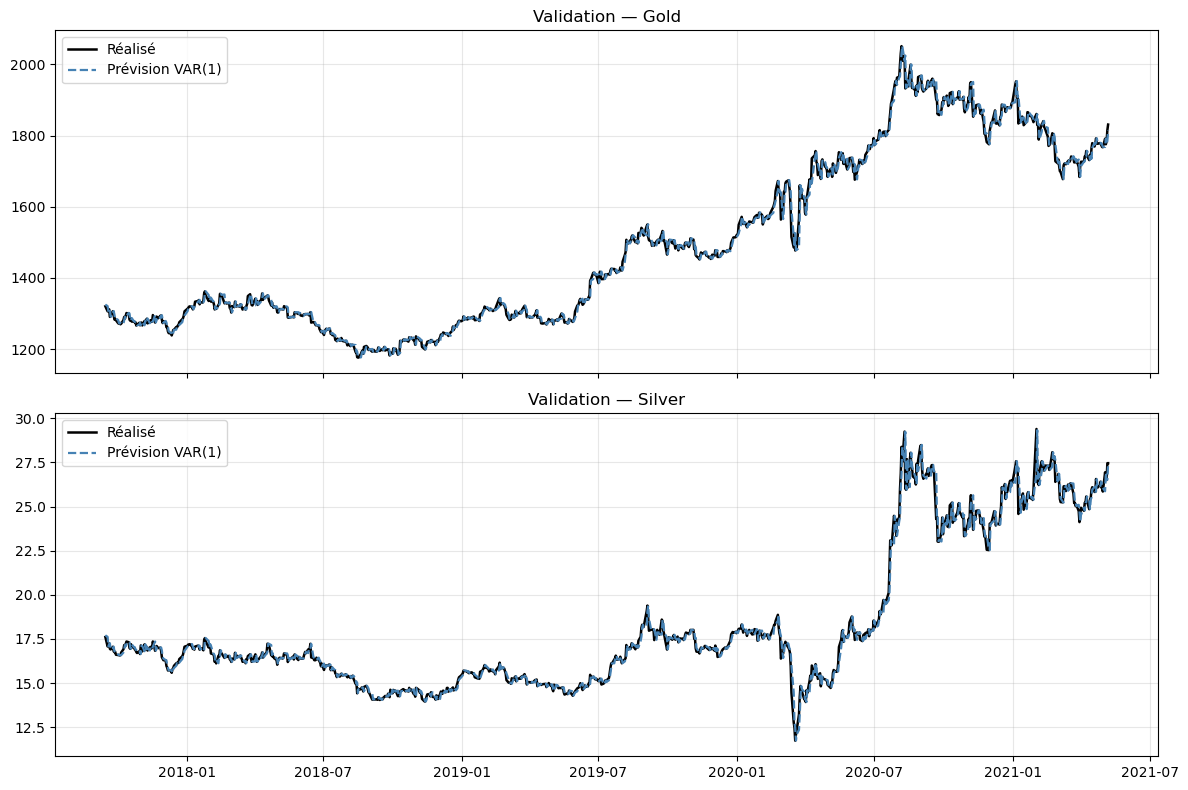

In [10]:
chosen_p = 1

plot_forecast_levels(
    act_levels=validation_results[chosen_p]["act_price_levels"],
    pred_levels=validation_results[chosen_p]["pred_price_levels"],
    columns=["log_gold", "log_silver"],
    model_label=f"VAR({chosen_p})",
    sample_label="Validation",
    variable_labels={"log_gold": "Gold", "log_silver": "Silver"},
)


The predicted (dashed) and realized (solid) series are visually almost 
indistinguishable, for both gold and silver. The VAR(1) forecast 
tracks every move, including the sharp spikes and dips. This matches 
the near-zero MAPE seen in the table, but it's important to read this 
plot for what it actually shows: a one-step-ahead forecast, re-anchored 
every day on the last observed price. It confirms the model doesn't 
drift or accumulate error, not that it has real forecasting power,
predicting "tomorrow ≈ today" is trivially accurate for series this 
close to a random walk, which is consistent with the earlier finding 
that lagged returns aren't significant.

### 1.5 Evaluation on the test sample of the bivariate VAR

In [11]:
test_start_idx = diff_data_full.index.searchsorted(df_test.index[0])
test_end_idx = diff_data_full.index.searchsorted(df_test.index[-1], side="right")

fc_test = recursive_one_step_forecast_var(
    diff_data_full=diff_data_full,
    log_data_full=log_data_full,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    p=chosen_p,
)

pred_levels_test = np.exp(fc_test["pred_levels"])
act_levels_test = np.exp(fc_test["act_levels"])

test_metrics = forecast_accuracy_table(pred_levels_test, act_levels_test)
test_metrics["Lag"] = chosen_p

test_metrics

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,RMSE,MAE,MAPE_%,Lag
Variable,,,,
log_gold,18.633947,13.676820,0.678026,1
log_silver,0.457052,0.333308,1.355087,1


On the held-out test set, MAPE rises slightly compared to validation 
(0.68% for gold vs. 0.65%, 1.36% for silver vs. 1.25%), which is 
expected and reassuring, a model shouldn't perform *better* on 
truly unseen data. The gap is small enough to say the VAR(1) 
generalizes consistently, without overfitting to the validation 
window. Gold remains the more accurately forecast series in relative 
terms, and the gold/silver gap stays roughly the same 2x ratio seen 
on validation, confirming this is a stable feature of the data 
(silver's higher volatility) rather than an artifact of one specific 
period.

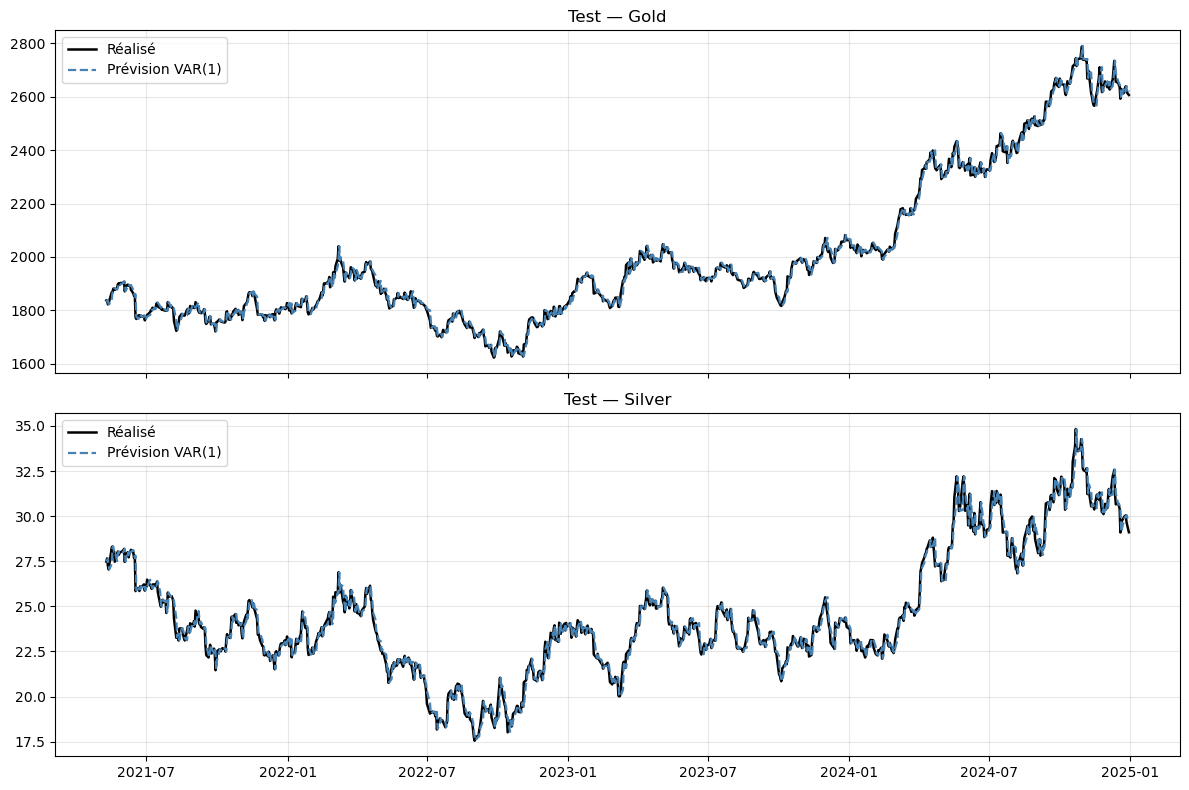

In [12]:
plot_forecast_levels(
    act_levels=act_levels_test,
    pred_levels=pred_levels_test,
    columns=["log_gold", "log_silver"],
    model_label=f"VAR({chosen_p})",
    sample_label="Test",
    variable_labels={"log_gold": "Gold", "log_silver": "Silver"},
)

Same pattern holds on the test set: the VAR(1) forecast tracks the 
realized series closely across both the calmer periods and the sharp 
2024-25 rally in gold and silver, with no visible drift or lag between 
the two lines. This confirms the out-of-sample behavior is stable 
across a different, unseen time period, not something specific to 
the validation window. As before, this accuracy reflects the model 
tracking a near-random-walk series one step at a time, rather than 
genuine multi-day predictive power.

### 1.6 Re-estimation on the full sample

In [13]:
df_var_final = clean_for_model(df[["dlog_gold", "dlog_silver"]])

final_var_full = VAR(df_var_final).fit(chosen_p)

print(final_var_full.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 15, Aug, 2026
Time:                     04:29:35
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -17.8245
Nobs:                     6106.00    HQIC:                  -17.8288
Log likelihood:           37116.3    FPE:                1.80319e-08
AIC:                     -17.8311    Det(Omega_mle):     1.80142e-08
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000370         0.000139            2.656           0.008
L1.dlog_gold          -0.002539         0.020486           -0.124           0.901
L1.dlog_silver        -0.008322         0.011268    

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Re-estimating VAR(1) on the full dataset (Nobs=6106) confirms the 
validation-period findings: no significant lagged effects (p=0.901 
and p=0.460 for gold) and a stable contemporaneous correlation 
(0.78, essentially unchanged from the 4273-observation subsample). 
This rules out the possibility that the earlier results were 
specific to a particular sub-period.

### 1.7 Residual diagnostics: VAR(1), and robustness under VAR(2) / VAR(4)

To assess the sensitivity of the residual diagnostics to the choice of lag,
alternative specifications VAR(2) and VAR(4) are also estimated. This
complementary analysis checks whether adding more dynamics improves the
residual properties (autocorrelation, normality) without questioning the
choice of the main retained model.

In [14]:
diagnostics_alt = var_diagnostics_table(df_var_final, candidates=[chosen_p, 2, 4], nlags_whiteness=12)
diagnostics_alt

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,Whiteness p-value,Normalité p-value
Lag,,,,
1,-17.831124,-17.824524,5.655671e-07,0.0
2,-17.831786,-17.820784,4.912296e-06,0.0
4,-17.831066,-17.811257,8.644445e-06,0.0


AIC/BIC remain essentially flat across lags 1, 2 and 4 (differences in the
4th decimal), confirming that information criteria don't discriminate
between these specifications. Whiteness p-values stay far below 5% at every
lag (5.7e-07 to 8.6e-06) and normality p-values are at 0.0 throughout. So
residual autocorrelation and non-normality persist regardless of lag order,
including at VAR(4). This confirms the point already made in section 1.2:
extra lags don't fix the residual diagnostics, which supports keeping the
parsimonious VAR(1) rather than moving to VAR(2) or VAR(4) for that reason.

## 2. VECM on the main cointegration episode

### 2.1 Identification of the cointegration episode

I isolate the longest episode detected by the rolling Engle-Granger test (notebook 02) and use it as the estimation window for the VECM.

In [15]:
rolling_eg = rolling_cointegration(df, target="log_gold", features=["log_silver"], window=1000)
intervals_df = find_significant_intervals(rolling_eg["p_value"], threshold=0.05)

In [16]:
best_interval = intervals_df.iloc[0]
start, end = best_interval["Start"], best_interval["End"]

print(f"Selected cointegration episode: {start.date()} → {end.date()} "
      f"({best_interval['N_observations']} observations)")

vecm_data = df.loc[start:end, ["log_gold", "log_silver"]].dropna().copy()

Selected cointegration episode: 2015-05-05 → 2016-02-12 (197 observations)


### 2.2 Lag selection and local Johansen test

In [17]:
lag_order = select_vecm_lag_order(vecm_data, maxlags=10, deterministic="co")
lag_order.summary()

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,AIC,BIC,FPE,HQIC
0,-18.33*,-18.19*,1.096e-08*,-18.27*
1,-18.30,-18.09,1.133e-08,-18.21
2,-18.31,-18.03,1.121e-08,-18.19
3,-18.32,-17.98,1.103e-08,-18.18
4,-18.29,-17.87,1.141e-08,-18.12
5,-18.27,-17.79,1.162e-08,-18.07
6,-18.29,-17.73,1.146e-08,-18.06
7,-18.25,-17.62,1.191e-08,-17.99
8,-18.25,-17.56,1.188e-08,-17.97
9,-18.23,-17.46,1.218e-08,-17.92


AIC selects k_ar_diff = 0, meaning the VECM has no short-run dynamics beyond
the error-correction term itself. This is a boundary case, similar to the
lag-0 ambiguity already noted for the VAR in §1.1, and the original study
does not discuss it further for this local window.

Despite this ambiguity, k_ar_diff = 0 is kept: the resulting model produces
an economically plausible long-run relation (§2.5), and the impulse response
functions (notebook 04) are smooth, convergent, and free of any numerical
instability,the kind of pathological behavior an under-specified lag order
would typically produce. The fact that both the statistical output (β, α,
IRF) and the economic interpretation (gold as price leader, silver as
follower) remain coherent is treated here as sufficient justification to
retain this specification, even though the lag choice itself was not
independently stress-tested.

In [18]:
k_ar_diff = lag_order.aic
print("Selected k_ar_diff:", k_ar_diff)

johansen_test = coint_johansen(vecm_data, det_order=0, k_ar_diff=k_ar_diff)
print("Trace stats:", johansen_test.lr1)
print("Critical values (5%):", johansen_test.cvt[:, 1])

Selected k_ar_diff: 0
Trace stats: [20.67615012  2.59524997]
Critical values (5%): [15.4943  3.8415]


### 2.3 Stationarity on the sub-period

In [19]:
vecm_data_ext = df.loc[start:end, ["log_gold", "log_silver", "log_ratio"]].dropna()
vecm_diff_ext = vecm_data_ext.diff().dropna()

level_table_vecm = stationarity_table(vecm_data_ext)
diff_table_vecm = stationarity_table(vecm_diff_ext)

print("Levels")
level_table_vecm

Levels


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,0.164163,0.736158,Non stationnaire,0.846121,0.01,Non stationnaire
log_silver,-0.260073,0.591369,Non stationnaire,1.140613,0.01,Non stationnaire
log_ratio,0.590823,0.844910,Non stationnaire,1.067374,0.01,Non stationnaire


In [20]:
print("First differences")
diff_table_vecm

First differences


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,-2.927806,3.353212e-03,Stationnaire,0.386726,0.082877,Stationnaire
log_silver,-14.981472,1.253880e-26,Stationnaire,0.156204,0.100000,Stationnaire
log_ratio,-15.250943,5.986871e-27,Stationnaire,0.030810,0.100000,Stationnaire


### 2.4 Estimation of the bivariate VECM

In [21]:
print("VECM period:", start.date(), "→", end.date())
print("Number of observations:", len(vecm_data))

vecm_res = fit_vecm(vecm_data, k_ar_diff=k_ar_diff, coint_rank=1, deterministic="co")
vecm_res.summary()

VECM period: 2015-05-05 → 2016-02-12
Number of observations: 197


c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.1934,0.131,-1.478,0.139,-0.450,0.063
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.5832,0.213,-2.739,0.006,-1.000,-0.166
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0420,0.028,1.480,0.139,-0.014,0.098
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.1265,0.046,2.738,0.006,0.036,0.217
,coef,std err,z,P>|z|,[0.025,0.975]
beta.1,1.0000,0,0,0.000,1.000,1.000
beta.2,-0.8929,0.140,-6.359,0.000,-1.168,-0.618


#### VECM estimation : episode window (May 2015 - Feb 2016)

The cointegration vector is highly significant (beta_silver = -0.893, 
p<0.001), confirming a stable long-run relationship between gold and 
silver over this episode. The adjustment dynamics are asymmetric: 
silver's loading coefficient is significant (alpha=0.127, p=0.006) 
while gold's is not (alpha=0.042, p=0.139). This means silver does 
the correcting when the two series drift apart from their long-run 
relationship, while gold does not react to the disequilibrium — 
consistent with gold acting as the price leader and silver as the 
follower during this episode.

### 2.5 Methodological discussion

The original idea was to use a VECM to model the long-run relation between
gold and silver prices. However, several methodological difficulties emerged
during the analysis.

The global cointegration tests (Engle-Granger and Johansen) do not show a
stable cointegration relation over the full sample. The rolling approach, by
contrast, reveals occasional cointegration episodes, in particular between
2015 and 2016.

The main issue then became: is it econometrically sound to estimate a VECM
over a relatively short period (197 observations) detected precisely because
it exhibits cointegration?

Rigorously, this approach has several limitations:

- the sample size remains small for a multivariate dynamic system;
- the window is selected endogenously, after cointegration is detected;
- results may be sensitive to the exact choice of dates and lag order;
- this prevents concluding that a stable structural relation holds over the
  whole period studied.

For these reasons, the VECM cannot be considered here as the central model of
the project.

Nevertheless, several elements make the results consistent and interesting
enough to keep this analysis as a local exploration of a specific episode.

The impulse response functions obtained (covered in notebook 04) are
economically consistent: the responses are smooth and convergent, the
dynamics show no explosion or numerical instability, and a shock on gold
leads to a positive response of silver.

The estimated cointegration vector:

$$\log(gold_t) - 0.8929 \log(silver_t) = 0$$

is economically plausible (positive coefficient, close to 1, statistically
significant). The analysis of the adjustment coefficients reveals that gold
is not significant (price leader) while silver adjusts (price follower),
which is consistent with market reality.

The VECM is kept not as definitive evidence of a stable structural relation,
but as an exploratory tool to study locally the transmission mechanisms
observed during this episode.

### 2.6 Long-run relation: beta vector

In [22]:
variable_names = ["log_gold", "log_silver"]

beta_table, alpha_table = vecm_beta_alpha_tables(vecm_res, variable_names)
beta_table

,Variable,Beta,Std_Error,t_stat,p_value
0,log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,log_silver,-0.892944,0.140416,-6.359255,2.027352e-10


### 2.7 Adjustment coefficients: alpha vector

In [23]:
alpha_table

,Equation,Alpha,Std_Error,t_stat,p_value
0,dlog_gold,0.042014,0.028390,1.479894,0.138901
1,dlog_silver,0.126475,0.046198,2.737679,0.006187


### 2.8 Normalized relation and error correction term (ECT)

In [24]:
long_run = normalized_long_run_relation(vecm_res, variable_names, normalize_on=0)

print("Estimated raw beta vector:")
print(f"{long_run['beta_raw'][0]:.4f} * log_gold + ({long_run['beta_raw'][1]:.4f}) * log_silver = 0")

print("\nLong-run relation, normalized on log_gold:")
print(long_run["equation_str"])

Estimated raw beta vector:
1.0000 * log_gold + (-0.8929) * log_silver = 0

Long-run relation, normalized on log_gold:
log_gold = -((-0.8929) * log_silver)


This elasticity is close to 1, indicating that gold and silver move 
almost proportionally in the long run, consistent with both being 
precious metals exposed to similar macro drivers (dollar strength, 
interest rates, inflation expectations). Note that this beta 
coefficient describes the equilibrium relationship itself, not the 
direction of adjustment: which series corrects toward this 
equilibrium is captured separately by the alpha coefficients, where 
gold was found to lead and silver to adjust.

In [25]:
vecm_data["ECT"] = compute_ect(vecm_data, long_run["beta_normalized"], variable_names)

vecm_data[["log_gold", "log_silver", "ECT"]].tail()

,log_gold,log_silver,ECT
Date,,,
2016-02-08,7.088325,2.735406,4.645761
2016-02-09,7.088993,2.737221,4.644808
2016-02-10,7.085650,2.726348,4.651174
2016-02-11,7.129217,2.759313,4.665305
2016-02-12,7.122141,2.759060,4.658454


Sample ECT values, showing the term stays in a narrow range 
(4.64–4.67) over these dates, consistent with gold and silver 
tracking their estimated long-run relationship closely during 
this part of the episode.

### 2.9 Summary table: bivariate VECM

In [26]:
summary_table = vecm_summary_table(beta_table, alpha_table)
summary_table

,Bloc,Nom,Coefficient,Std_Error,t_stat,p_value
0,Long terme (beta),log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,Long terme (beta),log_silver,-0.892944,0.140416,-6.359255,2.027352e-10
2,Ajustement (alpha),dlog_gold,0.042014,0.028390,1.479894,1.389015e-01
3,Ajustement (alpha),dlog_silver,0.126475,0.046198,2.737679,6.187446e-03


### 2.10 Out-of-sample validation: bivariate VECM

The VECM is re-estimated at each step using only the history available up to
t−1, and used to forecast the log-levels one step ahead. Note that,each re-estimation uses the full
available history (2000 onward) up to t−1, not only the local 2015–2016
cointegration window used to fit `vecm_res` above, this validation therefore
tests the walk-forward forecasting procedure itself rather than the
locally-estimated long-run relation specifically. Reconstructed levels are
compared to the realizations.

In [27]:
log_cols_bi = ["log_gold", "log_silver"]

vecm_data_full = clean_for_model(df[log_cols_bi])

val_start_bi = vecm_data_full.index.searchsorted(df_val.index[0])
val_end_bi = vecm_data_full.index.searchsorted(df_val.index[-1], side="right")

pred_log_val_bi, act_log_val_bi = recursive_one_step_forecast_vecm(
    vecm_data_full=vecm_data_full,
    log_cols=log_cols_bi,
    start_idx=val_start_bi,
    end_idx=val_end_bi,
    k_ar_diff=k_ar_diff,
    coint_rank=1,
    deterministic="co",
)

pred_levels_val_bi = np.exp(pred_log_val_bi)
act_levels_val_bi = np.exp(act_log_val_bi)

metrics_val_bi = forecast_accuracy_table(pred_levels_val_bi, act_levels_val_bi)
print("Validation metrics: bivariate VECM")
metrics_val_bi

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

Validation metrics: bivariate VECM


,RMSE,MAE,MAPE_%
Variable,,,
log_gold,15.528625,10.095198,0.650328
log_silver,0.418635,0.244097,1.258861


MAPE is nearly identical to the full-sample VAR (0.65% for gold, 
1.26% for silver), suggesting the VECM's error-correction mechanism 
does not meaningfully improve one-step-ahead accuracy over this 
episode compared to a model without long-run correction, consistent 
with the earlier finding that this relationship is a local, 
exploratory result rather than the project's central forecasting 
tool.

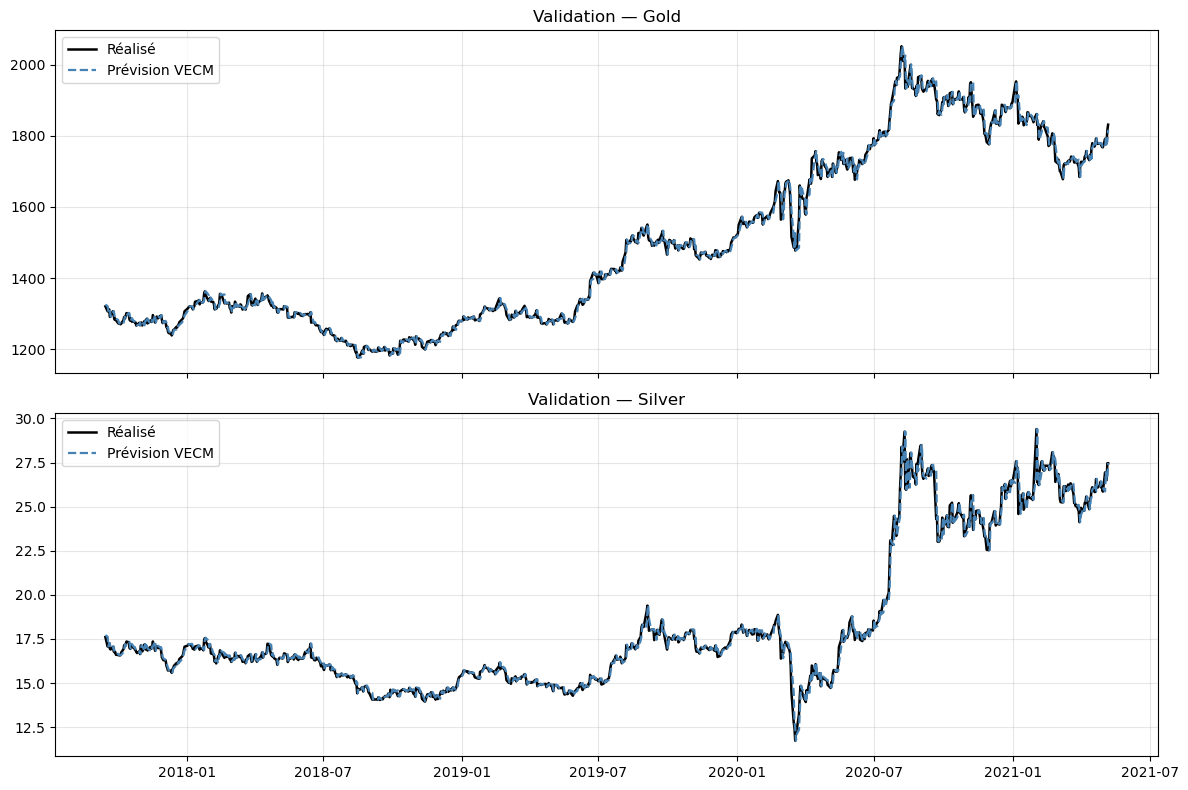

In [28]:
plot_forecast_levels(
    act_levels=act_levels_val_bi,
    pred_levels=pred_levels_val_bi,
    columns=log_cols_bi,
    model_label="VECM",
    sample_label="Validation",
    variable_labels={"log_gold": "Gold", "log_silver": "Silver"},
)

### 2.11 Evaluation on the test sample: bivariate VECM

In [ ]:
test_start_bi = vecm_data_full.index.searchsorted(df_test.index[0])
test_end_bi = vecm_data_full.index.searchsorted(df_test.index[-1], side="right")

pred_log_test_bi, act_log_test_bi = recursive_one_step_forecast_vecm(
    vecm_data_full=vecm_data_full,
    log_cols=log_cols_bi,
    start_idx=test_start_bi,
    end_idx=test_end_bi,
    k_ar_diff=k_ar_diff,
    coint_rank=1,
    deterministic="co",
)

pred_levels_test_bi = np.exp(pred_log_test_bi)
act_levels_test_bi = np.exp(act_log_test_bi)

metrics_test_bi = forecast_accuracy_table(pred_levels_test_bi, act_levels_test_bi)
print("Test metrics: bivariate VECM")
metrics_test_bi

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

Test metrics: bivariate VECM


,RMSE,MAE,MAPE_%
Variable,,,
log_gold,18.633948,13.665828,0.677606
log_silver,0.456870,0.333068,1.354275


### 2.12 Re-estimation of the bivariate VECM on the full sample

The VECM is re-estimated on the full sample with the retained `k_ar_diff`.

In [31]:
vecm_full_bi = fit_vecm(vecm_data_full[log_cols_bi], k_ar_diff=k_ar_diff, coint_rank=1, deterministic="co")
print(vecm_full_bi.summary())

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0038      0.002     -1.649      0.099      -0.008       0.001
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0115      0.004     -2.750      0.006      -0.020      -0.003
              Loading coefficients (alpha) for equation log_gold              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1            0.0011      0.001      1.812      0.070   -9.19e-05       0.002
             Loading coefficient

Re-estimated on the full sample, the cointegration vector shifts to
β = -1.1880 (log_silver, t = -9.27, p < 0.001) — notably different from
the -0.8929 estimated locally on the 2015–2016 episode in §2.4/§2.6. This
divergence is expected and consistent with the instability already discussed
in notebook 02 and in §2.5: the long-run relation is not stable across the
full sample, so re-estimating over 2000–2024 captures a different (and, per
the earlier discussion, less economically meaningful) average relationship
rather than confirming the local one.

The adjustment coefficients preserve the same qualitative pattern as the
local estimation: `log_gold`'s ec1 loading (0.0011, p = 0.070) is not
significant at 5%, while `log_silver`'s (0.0032, p = 0.005) is — silver
continues to be the variable that corrects toward equilibrium, gold does
not. This part of the story is robust to the choice of estimation window,
even though the equilibrium relation itself is not.

In [32]:
diag_bi = vecm_residual_diagnostics(vecm_full_bi, log_cols_bi, lags=12)
diag_bi

,Série,LB stat,p-value,Décision
0,log_gold (résidus),30.262529,0.002549,Rejet H0 (autocorrélation)
1,log_silver (résidus),23.584486,0.023154,Rejet H0 (autocorrélation)


Residual autocorrelation at lag 12 for both equations (log_gold:
LB p = 0.0025; log_silver: LB p = 0.0231) is expected here, not concerning:
this full-sample VECM forces one long-run relation onto 26 years of data,
but §2.5 and notebook 02 already show that relation only holds locally,
in 2015–2016. Imposing a single equilibrium outside the window where it
actually exists is exactly what produces autocorrelated residuals. Rather
than undermining the VECM, this confirms the decision to restrict it to the
episode where its core assumption is valid.

## 3. Conclusion

VAR(1) on log-returns is retained as the main short-term model for the
gold-silver pair. Out-of-sample accuracy is satisfactory (MAPE well below
2% on the test sample), even though residual diagnostics show autocorrelation
and non-normality regardless of the lag order tested (§1.2, §1.7). This is
not treated as a specification failure to be fixed by adding lags — daily
financial returns are well known to exhibit volatility clustering and fat
tails that a linear VAR, by construction, cannot capture; what the model *is*
built to capture (the average linear dynamics and the strong contemporaneous
dependence between the two metals, ≈0.78 residual correlation) it captures
well, as confirmed by the forecasting accuracy.

The bivariate VECM, estimated locally on the 2015–2016 cointegration episode,
gives an economically plausible long-run relation (β ≈ 0.8929, gold as price
leader / silver as price follower). Re-estimated on the full sample, the
VECM's residuals show significant autocorrelation at lag 12 (§2.12). This is
consistent with — rather than contradictory to — the conclusion already
reached in notebook 02 and in §2.5: the cointegration relation itself is not
stable over 2000–2024, so a single VECM specification fit to the whole period
is misspecified almost by definition, and residual autocorrelation is the
statistical symptom of that instability rather than an artifact of lag choice
or estimation error. It confirms, rather than undermines, the decision to
treat the VECM as a local, exploratory tool tied to a specific episode
instead of the project's central model.

Taken together, the two results are complementary: the VAR(1) is the
statistically honest choice for the full-sample short-term dynamics (accepted
residual imperfections included), while the VECM is deliberately restricted
to the one window where a long-run equilibrium is actually detectable —
using it outside that window, as the full-sample re-estimation illustrates,
reintroduces exactly the misspecification that motivated the restriction in
the first place.

Granger and instantaneous causality tests, the Cholesky decomposition, the
impulse response functions and the FEVD for both the VAR and the VECM are
covered in `04_Causality_and_IRF.ipynb`.